# News-Based Alpha Signals: From Text to Factors

**Chapter 10: Text Feature Engineering**

**Docker image**: `ml4t-gpu`

**Section Reference**: See Section 10.5 for practitioner workflow and alpha factor design

## Purpose
This notebook demonstrates how to construct alpha factors from financial news text.
We move beyond sentiment classification to build systematic signals that can be
evaluated using standard factor analysis techniques.

The "news surprise" concept follows Bhargava, Lou, Ozik, Sadka & Whitmore (2023)
"Quantifying Narratives and their impact on Financial Markets," which shows that
semantic deviation from recent narrative patterns predicts abnormal returns.

## Learning Objectives
After completing this notebook, you will be able to:
- Process large-scale financial news data from FNSPID dataset
- Compute news embeddings using sentence transformers
- Construct a "news surprise" factor measuring semantic deviation
- Aggregate signals by stock and date for factor evaluation
- Handle look-ahead bias in text-based factor construction
- Evaluate factor information coefficients (IC) against actual returns
- Analyze quintile spreads for practical signal assessment

## Cross-References
- **Foundation**: Section 10.4 covers Transformer embeddings
- **Factor Evaluation**: Chapter 9 covers IC analysis and factor evaluation
- **Application**: Chapter 16 shows how factors integrate into trading strategies
- **Academic**: Bhargava et al. (2023) for narrative impact on markets

In [1]:
"""News-Based Alpha Signals — construct and evaluate alpha factors from financial news text."""

import json
import warnings
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
from scipy.spatial.distance import cosine
from transformers import AutoModel, AutoTokenizer
from transformers import set_seed as set_transformers_seed

from data import load_fnspid
from utils.paths import get_chapter_dir
from utils.reproducibility import set_global_seeds

warnings.filterwarnings("ignore")

pl.Config.set_fmt_str_lengths(80)

polars.config.Config

In [2]:
SEED = 42
MAX_ARTICLES = 50000
MAX_TICKERS = 50
LOOKBACK_DAYS = 20
SIGNAL_LAG_DAYS = 1

In [3]:
# Reproducibility — set_global_seeds covers Python random / NumPy / Torch.
# transformers RNG (used by Trainer + pipelines) needs explicit seeding.
set_global_seeds(SEED)
set_transformers_seed(SEED)


def _safe_scalar(value: float | None, default: float = 0.0) -> float:
    """Return a finite float for reporting and plotting paths."""
    if value is None:
        return default
    try:
        value = float(value)
    except (TypeError, ValueError):
        return default
    if np.isnan(value):
        return default
    return value


CONFIG = {
    "random_seed": SEED,
    "embedding_model": "sentence-transformers/all-MiniLM-L6-v2",
    "sentiment_model": "yiyanghkust/finbert-tone",
    "lookback_days": 20,
    "signal_lag_days": 1,  # News from day t -> signal usable on day t+1
    "dedup_threshold": 0.9,  # Unused: dedup is exact + prefix-hash, kept for API compat
}

print("=" * 70)
print("EXPERIMENT CONFIGURATION")
print("=" * 70)
print(json.dumps(CONFIG, indent=2))
print("=" * 70)

EXPERIMENT CONFIGURATION
{
  "random_seed": 42,
  "embedding_model": "sentence-transformers/all-MiniLM-L6-v2",
  "sentiment_model": "yiyanghkust/finbert-tone",
  "lookback_days": 20,
  "signal_lag_days": 1,
  "dedup_threshold": 0.9
}


In [4]:
# Apply Papermill-injected runtime controls after the parameters cell executes.
CONFIG["lookback_days"] = LOOKBACK_DAYS
CONFIG["signal_lag_days"] = SIGNAL_LAG_DAYS
CONFIG["max_articles"] = MAX_ARTICLES
CONFIG["max_tickers"] = MAX_TICKERS

## Load Financial News Data

We use the **FNSPID** (Financial News and Stock Price Integration Dataset) from HuggingFace,
containing 15.7M financial news articles with stock tickers and dates (1999-2023).

**Dataset sizing**:
- Default download: **1M articles** (sufficient for this demonstration)
- Full dataset: 15.7M articles (requires more processing time)

To download or change sample size:
```bash
python data/text/fnspid_download.py              # Default: 1M sample
python data/text/fnspid_download.py --sample 0   # Full 15.7M dataset
```

Reference: [FNSPID on HuggingFace](https://huggingface.co/datasets/Zihan1004/FNSPID)

In [5]:
# Load FNSPID dataset
print("Loading FNSPID financial news dataset...")
news_df = load_fnspid()
print(f"Loaded {len(news_df):,} articles from canonical local storage")
print("(Full FNSPID dataset contains 15.7M articles; local sample may be smaller)")

print(f"\nDataset shape: {news_df.shape}")
news_df.head(5)

Loading FNSPID financial news dataset...
Loaded 1,000,000 articles from canonical local storage
(Full FNSPID dataset contains 15.7M articles; local sample may be smaller)

Dataset shape: (1000000, 11)


timestamp,Article_title,ticker,Url,Publisher,Author,Article,Lsa_summary,Luhn_summary,Textrank_summary,Lexrank_summary
str,str,str,str,str,null,null,null,null,null,null
"""2020-06-05 06:30:54 UTC""","""Stocks That Hit 52-Week Highs On Friday""","""A""","""https://www.benzinga.com/news/20/06/16190091/stocks-that-hit-52-week-highs-on-fr…","""Benzinga Insights""",null,null,null,null,null,null
"""2020-06-03 06:45:20 UTC""","""Stocks That Hit 52-Week Highs On Wednesday""","""A""","""https://www.benzinga.com/news/20/06/16170189/stocks-that-hit-52-week-highs-on-we…","""Benzinga Insights""",null,null,null,null,null,null
"""2020-05-26 00:30:07 UTC""","""71 Biggest Movers From Friday""","""A""","""https://www.benzinga.com/news/20/05/16103463/71-biggest-movers-from-friday""","""Lisa Levin""",null,null,null,null,null,null
"""2020-05-22 08:45:06 UTC""","""46 Stocks Moving In Friday's Mid-Day Session""","""A""","""https://www.benzinga.com/news/20/05/16095921/46-stocks-moving-in-fridays-mid-day…","""Lisa Levin""",null,null,null,null,null,null
"""2020-05-22 07:38:59 UTC""","""B of A Securities Maintains Neutral on Agilent Technologies, Raises Price Target…","""A""","""https://www.benzinga.com/news/20/05/16095304/b-of-a-securities-maintains-neutral…","""Vick Meyer""",null,null,null,null,null,null


In [6]:
# Examine dataset structure
print("Column names:", news_df.columns)
print("\nSample article:")
sample = news_df.head(1)
for col in news_df.columns:
    val = sample[col][0]
    if isinstance(val, str) and len(val) > 100:
        val = val[:100] + "..."
    print(f"  {col}: {val}")

Column names: ['timestamp', 'Article_title', 'ticker', 'Url', 'Publisher', 'Author', 'Article', 'Lsa_summary', 'Luhn_summary', 'Textrank_summary', 'Lexrank_summary']

Sample article:
  timestamp: 2020-06-05 06:30:54 UTC
  Article_title: Stocks That Hit 52-Week Highs On Friday
  ticker: A
  Url: https://www.benzinga.com/news/20/06/16190091/stocks-that-hit-52-week-highs-on-friday
  Publisher: Benzinga Insights
  Author: None
  Article: None
  Lsa_summary: None
  Luhn_summary: None
  Textrank_summary: None
  Lexrank_summary: None


## Data Preparation

Clean and structure the news data for factor construction.

In [7]:
# Standardize column names and extract key fields
# Column mapping depends on actual FNSPID structure
print("Preparing news data...")

# Identify the text, date, and ticker columns
# Priority: headline > title > text (to avoid matching "Textrank_summary")
text_col = None
date_col = None
ticker_col = None

for col in news_df.columns:
    col_lower = col.lower()
    # Text column: prefer headline/title over generic "text" matches
    if (
        "headline" in col_lower
        or "title" in col_lower
        and text_col is None
        or "text" in col_lower
        and "summary" not in col_lower
        and text_col is None
    ):
        text_col = col
    # Date column
    if ("date" in col_lower or col_lower == "timestamp") and "update" not in col_lower:
        date_col = col
    # Ticker column
    if "ticker" in col_lower or "asset" in col_lower or "stock" in col_lower and ticker_col is None:
        ticker_col = col

print(f"Text column: {text_col}")
print(f"Date column: {date_col}")
print(f"Ticker column: {ticker_col}")

Preparing news data...
Text column: Article_title
Date column: timestamp
Ticker column: ticker


In [8]:
# Standardize the DataFrame
if text_col and date_col and ticker_col:
    news_clean = news_df.select(
        [
            pl.col(ticker_col).alias("ticker"),
            pl.col(date_col).alias("timestamp"),
            pl.col(text_col).alias("headline"),
        ]
    )
else:
    # Fallback: use first string columns as proxies
    print("Warning: Could not auto-detect columns, using fallback")
    string_cols = [c for c in news_df.columns if news_df[c].dtype == pl.String]
    news_clean = news_df.select(
        [
            pl.col(string_cols[0]).alias("ticker")
            if len(string_cols) > 0
            else pl.lit("UNK").alias("ticker"),
            pl.col(string_cols[1]).alias("timestamp")
            if len(string_cols) > 1
            else pl.lit("2020-01-01").alias("timestamp"),
            pl.col(string_cols[2]).alias("headline")
            if len(string_cols) > 2
            else pl.lit("").alias("headline"),
        ]
    )

In [9]:
# Filter, normalize dates, and subsample
news_clean = news_clean.filter(
    pl.col("headline").is_not_null() & (pl.col("headline").str.len_chars() > 10)
)

# Ensure timestamp is String for uniform handling (loaders may return Date or String)
if news_clean["timestamp"].dtype != pl.String:
    news_clean = news_clean.with_columns(pl.col("timestamp").dt.strftime("%Y-%m-%d"))

if MAX_TICKERS > 0:
    top_tickers = (
        news_clean.group_by("ticker")
        .len()
        .sort("len", descending=True)
        .head(MAX_TICKERS)["ticker"]
        .to_list()
    )
    news_clean = news_clean.filter(pl.col("ticker").is_in(top_tickers))

if MAX_ARTICLES > 0 and len(news_clean) > MAX_ARTICLES:
    per_ticker_limit = max(MAX_ARTICLES // max(news_clean["ticker"].n_unique(), 1), 1)
    news_clean = (
        news_clean.sort(["ticker", "timestamp"])
        .group_by("ticker", maintain_order=True)
        .head(per_ticker_limit)
        .sort(["timestamp", "ticker"])
    )

print(f"\nCleaned dataset: {len(news_clean):,} articles")
news_clean.head(5)


Cleaned dataset: 50,000 articles


ticker,timestamp,headline
str,str,str
"""M""","""2009-06-16 00:00:00 UTC""","""AIM Great News the Day After Great Earnings"""
"""KO""","""2009-06-22 00:00:00 UTC""","""guest post - Best Buy's been a 'best buy'"""
"""MRK""","""2009-07-27 00:00:00 UTC""","""Wall Street News Alert: Stocks This Morning: Green Star Alternative Energy -- Ju…"
"""M""","""2009-08-06 00:00:00 UTC""","""SRS Class Action Lawsuit filed 08/05/2009"""
"""GPS""","""2009-08-07 00:00:00 UTC""","""BC Safety Council: Ban Cell Phones While Driving"""


## Text-to-Signal Pipeline Checklist

The chapter introduces a critical checklist for converting text to tradeable signals.
This section demonstrates each step with concrete implementations.

| Checklist Item | Implementation |
|----------------|----------------|
| Availability timestamp | Use publication date, lag signal by 1 day |
| Wire deduplication | Exact + 50-char prefix hash within (ticker, date) |
| Entity resolution | Normalize tickers to canonical symbols |

In [10]:
# ============================================================================
# TEXT-TO-SIGNAL PIPELINE DEMONSTRATION
# ============================================================================
print("=" * 70)
print("TEXT-TO-SIGNAL PIPELINE CHECKLIST")
print("=" * 70)

# --- 1. WIRE DEDUPLICATION ---
# News from different sources often contains near-duplicates from wire services.
# We use fast hash-based deduplication: normalize text → hash → keep first per group.

print("\n1. WIRE DEDUPLICATION")
print("-" * 40)

TEXT-TO-SIGNAL PIPELINE CHECKLIST

1. WIRE DEDUPLICATION
----------------------------------------


### Wire Deduplication
Remove near-duplicate articles using hash-based deduplication within each (ticker, date) group.

In [11]:
def deduplicate_news(
    df: pl.DataFrame,
    text_col: str,
    date_col: str,
    ticker_col: str,
    similarity_threshold: float = 0.9,  # Unused but kept for API compatibility
) -> tuple[pl.DataFrame, float]:
    """
    Remove duplicate news articles using hash-based deduplication.

    Wire duplicates typically have identical or near-identical headlines.
    We normalize text (lowercase, strip) and hash to detect exact duplicates
    within each (ticker, date) group. This is O(n) vs O(n²) for TF-IDF.

    For near-duplicates, we also hash the first 50 characters to catch
    articles that differ only in trailing content.

    Returns:
        Deduplicated DataFrame and the duplicate rate removed
    """
    import hashlib
    import re

    def normalize_text(text: str) -> str:
        """Normalize text for comparison: lowercase, remove punctuation, collapse whitespace."""
        if not text:
            return ""
        text = text.lower()
        text = re.sub(r"[^\w\s]", "", text)  # Remove punctuation
        text = re.sub(r"\s+", " ", text).strip()  # Collapse whitespace
        return text

    def text_hash(text: str) -> str:
        """Hash normalized text."""
        return hashlib.md5(normalize_text(text).encode()).hexdigest()

    def prefix_hash(text: str, n_chars: int = 50) -> str:
        """Hash first N characters (catches near-duplicates with different endings)."""
        normalized = normalize_text(text)
        return hashlib.md5(normalized[:n_chars].encode()).hexdigest()

    n_before = len(df)

    # Add hash columns
    df = df.with_columns(
        [
            pl.col(text_col).map_elements(text_hash, return_dtype=pl.String).alias("_full_hash"),
            pl.col(text_col)
            .map_elements(prefix_hash, return_dtype=pl.String)
            .alias("_prefix_hash"),
        ]
    )

    # Deduplicate: within each (ticker, date), keep first occurrence of each hash
    # Use full hash first, then prefix hash for near-duplicates
    df = df.unique(subset=[ticker_col, date_col, "_full_hash"], keep="first")
    df = df.unique(subset=[ticker_col, date_col, "_prefix_hash"], keep="first")

    # Clean up temporary columns
    df = df.drop(["_full_hash", "_prefix_hash"])

    n_after = len(df)
    dup_rate = (n_before - n_after) / max(n_before, 1)

    return df, dup_rate

In [12]:
# Apply deduplication
n_before = len(news_clean)
news_pre_dedup = news_clean  # snapshot of the raw corpus for the TF-IDF comparison below
news_clean, dup_rate = deduplicate_news(
    news_clean,
    text_col="headline",
    date_col="timestamp",
    ticker_col="ticker",
    similarity_threshold=CONFIG["dedup_threshold"],
)
n_after = len(news_clean)

print(f"   Articles before: {n_before:,}")
print(f"   Articles after:  {n_after:,}")
print(f"   Duplicates removed: {n_before - n_after:,} ({dup_rate:.1%})")
print("   Dedup method: exact + 50-char prefix hash within (ticker, date)")

   Articles before: 50,000
   Articles after:  49,090
   Duplicates removed: 910 (1.8%)
   Dedup method: exact + 50-char prefix hash within (ticker, date)


### Optional: TF-IDF near-duplicate comparison

The hash pass above is fast (O(n)) and removes exact and shared-prefix copies —
the bulk of wire-service duplication. It does not catch *paraphrased*
near-duplicates, where an editor rewords a headline enough to change its prefix.
A TF-IDF cosine-similarity pass within each (ticker, date) group catches those,
at O(n²) per group; here the groups are small, so the added cost is modest.

The two methods are complementary. The pipeline keeps the fast hash result as its
default; the comparison below runs the fuzzy pass on the same raw corpus and
reports what it would additionally remove, so you can weigh the trade-off and tune
the `dedup_threshold` cosine cutoff.

In [13]:
def deduplicate_news_tfidf(
    df: pl.DataFrame,
    text_col: str,
    date_col: str,
    ticker_col: str,
    similarity_threshold: float = 0.9,
) -> tuple[pl.DataFrame, float]:
    """Remove TF-IDF cosine near-duplicates within each (ticker, date) group.

    Complements the fast hash pass: the hash removes byte-identical and
    shared-prefix copies in O(n); this catches paraphrased near-duplicates the
    hash misses, at O(n²) per (ticker, date) group. Within each group the
    headlines are vectorized with TF-IDF and the first article in any pair whose
    cosine similarity meets ``similarity_threshold`` is kept while the rest are
    dropped (greedy single-link clustering).

    Returns:
        Deduplicated DataFrame and the duplicate rate removed.
    """
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.metrics.pairwise import cosine_similarity

    n_before = len(df)
    df = df.with_row_index("_tfidf_rid")
    kept: list[int] = []

    for _, grp in df.group_by([ticker_col, date_col], maintain_order=True):
        ids = grp["_tfidf_rid"].to_list()
        texts = [t or "" for t in grp[text_col].to_list()]
        if len(texts) < 2:
            kept.extend(ids)
            continue
        try:
            tfidf = TfidfVectorizer().fit_transform(texts)
        except ValueError:
            # Empty vocabulary (all empty/stopword headlines) — keep the group as-is.
            kept.extend(ids)
            continue
        sim = cosine_similarity(tfidf)
        dropped: set[int] = set()
        for i in range(len(texts)):
            if i in dropped:
                continue
            kept.append(ids[i])
            dropped.update(j for j in range(i + 1, len(texts)) if sim[i, j] >= similarity_threshold)

    df = df.filter(pl.col("_tfidf_rid").is_in(kept)).drop("_tfidf_rid")
    n_after = len(df)
    return df, (n_before - n_after) / max(n_before, 1)

In [14]:
# Side-by-side comparison on the same raw corpus. The pipeline keeps the hash
# result (news_clean); this cell is informational so the two strategies can be
# compared and the cosine cutoff tuned.
_cmp = news_pre_dedup.with_row_index("_rid")
_hash_kept, _ = deduplicate_news(_cmp, "headline", "timestamp", "ticker")
news_tfidf, tfidf_dup_rate = deduplicate_news_tfidf(
    _cmp,
    text_col="headline",
    date_col="timestamp",
    ticker_col="ticker",
    similarity_threshold=CONFIG["dedup_threshold"],
)

_all_ids = set(_cmp["_rid"].to_list())
_removed_hash = _all_ids - set(_hash_kept["_rid"].to_list())
_removed_tfidf = _all_ids - set(news_tfidf["_rid"].to_list())
_both = _removed_hash & _removed_tfidf
_union = _removed_hash | _removed_tfidf

print("\n1b. DEDUP METHOD COMPARISON (informational; pipeline uses the hash result)")
print("-" * 40)
print(f"   Hash   removed: {len(_removed_hash):,} ({dup_rate:.1%})")
print(f"   TF-IDF removed: {len(_removed_tfidf):,} ({tfidf_dup_rate:.1%})")
print(f"   Removed by both:        {len(_both):,}")
print(f"   TF-IDF only (paraphrased near-dups): {len(_removed_tfidf - _removed_hash):,}")
print(f"   Hash only:              {len(_removed_hash - _removed_tfidf):,}")
if _union:
    print(f"   Agreement (Jaccard of removed sets): {len(_both) / len(_union):.1%}")

# --- 2. ENTITY RESOLUTION ---
# Tickers may appear in different forms. Normalize to canonical symbols.

print("\n2. ENTITY RESOLUTION (Ticker Normalization)")
print("-" * 40)

# Common ticker variations to normalize
TICKER_ALIASES = {
    "GOOGL": "GOOG",  # Google class A/C
    "BRK.B": "BRK-B",  # Berkshire formatting
    "BRK.A": "BRK-A",
    "FB": "META",  # Historical rename
}


1b. DEDUP METHOD COMPARISON (informational; pipeline uses the hash result)
----------------------------------------
   Hash   removed: 910 (1.8%)
   TF-IDF removed: 943 (1.9%)
   Removed by both:        868
   TF-IDF only (paraphrased near-dups): 75
   Hash only:              42
   Agreement (Jaccard of removed sets): 88.1%

2. ENTITY RESOLUTION (Ticker Normalization)
----------------------------------------


### Ticker Normalization
Map ticker aliases to canonical symbols.

In [15]:
def normalize_ticker(ticker: str) -> str:
    """Normalize ticker to canonical form."""
    if ticker is None:
        return "UNKNOWN"
    ticker = ticker.upper().strip()
    return TICKER_ALIASES.get(ticker, ticker)


# Apply normalization
news_clean = news_clean.with_columns(
    pl.col("ticker")
    .map_elements(normalize_ticker, return_dtype=pl.String)
    .alias("ticker_normalized")
)

# Show normalization results
original_tickers = news_clean["ticker"].n_unique()
normalized_tickers = news_clean["ticker_normalized"].n_unique()
print(f"   Original unique tickers: {original_tickers:,}")
print(f"   After normalization: {normalized_tickers:,}")
print(f"   Aliases applied: {TICKER_ALIASES}")

# Use normalized ticker going forward
news_clean = news_clean.with_columns(pl.col("ticker_normalized").alias("ticker")).drop(
    "ticker_normalized"
)

# --- 3. AVAILABILITY TIMESTAMP (shown in Look-Ahead Bias section) ---
print("\n3. AVAILABILITY TIMESTAMP")
print("-" * 40)
print("   Implemented in 'Look-Ahead Bias' section below:")
print("   - signal_date: when news was published")
print("   - trade_date: signal_date + 1 (when signal can be USED)")
print("   - This ensures no look-ahead bias in factor construction")

print("\n" + "=" * 70)

   Original unique tickers: 50
   After normalization: 50
   Aliases applied: {'GOOGL': 'GOOG', 'BRK.B': 'BRK-B', 'BRK.A': 'BRK-A', 'FB': 'META'}

3. AVAILABILITY TIMESTAMP
----------------------------------------
   Implemented in 'Look-Ahead Bias' section below:
   - signal_date: when news was published
   - trade_date: signal_date + 1 (when signal can be USED)
   - This ensures no look-ahead bias in factor construction



## Compute News Embeddings

We use a pre-trained Transformer to convert headlines into dense vector representations.
These embeddings capture semantic meaning beyond keyword matching.

**Mean Pooling**: We average the token embeddings (weighted by attention mask) to get
a single fixed-size vector per headline. This is the standard approach for sentence embeddings.

In [16]:
# Load pre-trained model for embeddings
print("Loading embedding model...")
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)
model.eval()

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Model loaded on {device}: {MODEL_NAME}")

Loading embedding model...


Model loaded on cuda: sentence-transformers/all-MiniLM-L6-v2


### Mean Pooling
Average token embeddings weighted by attention mask to get a single sentence vector.

In [17]:
def mean_pooling(model_output, attention_mask):
    """Apply mean pooling to token embeddings, weighted by attention mask."""
    token_embeddings = model_output.last_hidden_state
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(
        input_mask_expanded.sum(1), min=1e-9
    )

### Encode Texts to Embeddings
Batch-encode texts using the Transformer model with mean pooling and L2 normalization.

In [18]:
def encode_texts(texts: list[str], batch_size: int = 32) -> np.ndarray:
    """Encode texts to embeddings using mean pooling."""
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]

        # Tokenize
        encoded = tokenizer(
            batch, padding=True, truncation=True, max_length=128, return_tensors="pt"
        )
        encoded = {k: v.to(device) for k, v in encoded.items()}

        # Get embeddings
        with torch.no_grad():
            output = model(**encoded)
            embeddings = mean_pooling(output, encoded["attention_mask"])
            # Normalize embeddings
            embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=1)
            all_embeddings.append(embeddings.cpu().numpy())

        if (i + batch_size) % 1000 == 0:
            print(f"  Processed {min(i + batch_size, len(texts)):,} / {len(texts):,}")

    return np.vstack(all_embeddings)

### Sentiment Scoring with FinBERT
Score headlines using FinBERT-tone for polarity (-1=Negative, 0=Neutral, +1=Positive).

In [19]:
def score_sentiment_finbert(
    texts: list[str], batch_size: int = 64
) -> tuple[np.ndarray, np.ndarray]:
    """
    Score sentiment using FinBERT (yiyanghkust/finbert-tone).

    Returns:
        scores: Array of polarity scores (-1=Negative, 0=Neutral, +1=Positive)
        confidences: Array of model confidence values
    """
    from transformers import pipeline

    print("Loading FinBERT sentiment model...")
    classifier = pipeline(
        "sentiment-analysis",
        model="yiyanghkust/finbert-tone",
        device=0 if torch.cuda.is_available() else -1,
        truncation=True,
        max_length=512,
    )

    label_to_score = {"Negative": -1.0, "Neutral": 0.0, "Positive": 1.0}

    all_scores = []
    all_confidences = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]

        # FinBERT returns label and score
        results = classifier(batch)

        for result in results:
            label = result["label"]
            confidence = result["score"]
            polarity = label_to_score.get(label, 0.0)
            all_scores.append(polarity)
            all_confidences.append(confidence)

        if (i + batch_size) % 5000 == 0:
            print(f"  Sentiment scored: {min(i + batch_size, len(texts)):,} / {len(texts):,}")

    return np.array(all_scores), np.array(all_confidences)

In [20]:
# Compute embeddings for all headlines
print("Computing embeddings for news headlines...")

headlines = news_clean["headline"].to_list()

# IMPORTANT: The order of the headlines list determines embedding array indices.
# We maintain a 1:1 mapping between news_clean rows and embeddings array positions.
# Do NOT sort or filter news_clean after this point without also updating embeddings.

# Encode using our mean pooling function
embeddings = encode_texts(headlines, batch_size=64)

print(f"Embedding shape: {embeddings.shape}")

# Add embeddings to DataFrame (as list column for now)
news_with_embeddings = news_clean.with_columns(
    pl.Series("embedding_idx", list(range(len(embeddings))))
)

Computing embeddings for news headlines...


  Processed 8,000 / 49,090


  Processed 16,000 / 49,090


  Processed 24,000 / 49,090


  Processed 32,000 / 49,090


  Processed 40,000 / 49,090


  Processed 48,000 / 49,090
Embedding shape: (49090, 384)


In [21]:
# Compute sentiment scores using FinBERT
print("\nScoring sentiment with FinBERT...")
sentiment_scores, sentiment_confidences = score_sentiment_finbert(headlines, batch_size=64)

print("Sentiment distribution:")
print(f"  Negative: {(sentiment_scores < 0).sum():,} ({(sentiment_scores < 0).mean() * 100:.1f}%)")
print(
    f"  Neutral:  {(sentiment_scores == 0).sum():,} ({(sentiment_scores == 0).mean() * 100:.1f}%)"
)
print(f"  Positive: {(sentiment_scores > 0).sum():,} ({(sentiment_scores > 0).mean() * 100:.1f}%)")

# Add sentiment to DataFrame
news_with_embeddings = news_with_embeddings.with_columns(
    [
        pl.Series("sentiment_score", sentiment_scores),
        pl.Series("sentiment_confidence", sentiment_confidences),
    ]
)


Scoring sentiment with FinBERT...


Loading FinBERT sentiment model...


Device set to use cuda:0


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  Sentiment scored: 40,000 / 49,090


Sentiment distribution:
  Negative: 7,421 (15.1%)
  Neutral:  30,158 (61.4%)
  Positive: 11,511 (23.4%)


## Construct News Surprise Factor

The "news surprise" factor measures how different today's news is from recent news
for each stock. High surprise may predict abnormal returns—capturing information
that's genuinely new to the market.

**Construction:**
1. For each stock-date, compute the average embedding of all news that day
2. Compute a rolling baseline (20-day average of daily embeddings)
3. Measure cosine distance between today's embedding and the baseline
4. High distance = high surprise (news content deviates from recent narrative)

In [22]:
# Aggregate embeddings by ticker and date
print("Aggregating news by ticker and date...")


def aggregate_by_ticker_date(
    news_df: pl.DataFrame, embeddings: np.ndarray, sentiment_scores: np.ndarray
) -> tuple[dict, pl.DataFrame]:
    """
    Aggregate embeddings and sentiment to ticker-date level.

    Returns:
        ticker_date_embeddings: Dict of ticker -> date -> mean embedding
        sentiment_agg: DataFrame with ticker, date, sentiment_mean, sentiment_std, coverage_count
    """
    ticker_date_data = defaultdict(lambda: defaultdict(lambda: {"embs": [], "sentiments": []}))

    # Use embedding_idx column for safe indexing (robust to DataFrame reordering)
    for row in news_df.iter_rows(named=True):
        ticker = row["ticker"]
        date = str(row["timestamp"])[:10]  # Truncate to YYYY-MM-DD
        idx = row["embedding_idx"]  # Use stored index, not row order
        ticker_date_data[ticker][date]["embs"].append(embeddings[idx])
        ticker_date_data[ticker][date]["sentiments"].append(sentiment_scores[idx])

    # Aggregate embeddings and sentiment
    aggregated_embeddings = {}
    sentiment_records = []

    for ticker, dates in ticker_date_data.items():
        aggregated_embeddings[ticker] = {}
        for date, data in dates.items():
            aggregated_embeddings[ticker][date] = np.mean(data["embs"], axis=0)

            sentiments = np.array(data["sentiments"])
            sentiment_records.append(
                {
                    "ticker": ticker,
                    "timestamp": date,
                    "sentiment_mean": float(np.mean(sentiments)),
                    "sentiment_std": float(np.std(sentiments)) if len(sentiments) > 1 else 0.0,
                    "coverage_count": len(sentiments),
                }
            )

    sentiment_agg = pl.DataFrame(sentiment_records)
    return aggregated_embeddings, sentiment_agg


ticker_date_embeddings, sentiment_by_ticker_date = aggregate_by_ticker_date(
    news_with_embeddings, embeddings, sentiment_scores
)

# Count tickers and coverage
n_tickers = len(ticker_date_embeddings)
total_ticker_dates = sum(len(dates) for dates in ticker_date_embeddings.values())
print(f"Tickers with news: {n_tickers:,}")
print(f"Total ticker-date observations: {total_ticker_dates:,}")

Aggregating news by ticker and date...


Tickers with news: 50
Total ticker-date observations: 21,779


### Compute News Surprise Factor
Measure cosine distance between today's embedding and a rolling 20-day baseline.

In [23]:
def compute_news_surprise(ticker_embeddings: dict, lookback: int = 20) -> pl.DataFrame:
    """
    Compute news surprise factor for each ticker-date.

    Surprise = cosine distance between today's embedding and
    rolling average of past `lookback` days' embeddings.

    **Important: Lookback is NEWS-DAYS, not TRADING-DAYS.**
    - We require `lookback` prior days WITH NEWS for that ticker
    - This means low-coverage tickers (sparse news) are dropped entirely
    - High-coverage tickers (frequent news) have more observations

    This design choice has implications:
    - Bias toward high-coverage tickers (typically large-cap, high attention)
    - Production systems may prefer trading-day lookback with missing-news handling
    """
    results = []

    for ticker, date_embeddings in ticker_embeddings.items():
        # Sort dates (these are NEWS dates, not trading calendar dates)
        sorted_dates = sorted(date_embeddings.keys())

        if len(sorted_dates) < lookback + 1:
            continue  # Need enough NEWS history - drops low-coverage tickers

        for i in range(lookback, len(sorted_dates)):
            current_date = sorted_dates[i]
            current_emb = date_embeddings[current_date]

            # Compute baseline: average of past `lookback` NEWS days
            past_embs = [date_embeddings[sorted_dates[j]] for j in range(i - lookback, i)]
            baseline_emb = np.mean(past_embs, axis=0)

            # Cosine distance (1 - cosine similarity)
            surprise = cosine(current_emb, baseline_emb)

            results.append({"ticker": ticker, "timestamp": current_date, "news_surprise": surprise})

    return pl.DataFrame(results)

### Create Directional Features
Combine surprise with sentiment direction for a tradeable signal.

In [24]:
def create_directional_features(
    surprise_df: pl.DataFrame, sentiment_df: pl.DataFrame, lookback: int = 20
) -> pl.DataFrame:
    """
    Create directional news features combining surprise with sentiment.

    Key insight: "Different" alone is useless. We need surprise × sentiment_direction
    for a tradeable signal.

    Features created:
    - news_surprise: Semantic deviation from 20-day baseline (0-1)
    - sentiment_mean: Average FinBERT polarity (-1 to +1)
    - sentiment_std: Polarity disagreement across articles
    - weighted_surprise: surprise × sign(sentiment) - THE KEY FEATURE
    - sentiment_momentum: Change in avg sentiment vs lookback period
    - coverage_count: Article count per ticker-date
    """
    # Merge surprise with sentiment aggregates
    features = surprise_df.join(sentiment_df, on=["ticker", "timestamp"], how="inner")

    # Add directional feature: weighted_surprise = surprise × sign(sentiment)
    # Positive sentiment + high surprise = bullish signal
    # Negative sentiment + high surprise = bearish signal
    features = features.with_columns(
        (pl.col("news_surprise") * pl.col("sentiment_mean").sign()).alias("weighted_surprise")
    )

    # Compute sentiment momentum: change in sentiment vs lookback period
    features = features.sort(["ticker", "timestamp"]).with_columns(
        (pl.col("sentiment_mean") - pl.col("sentiment_mean").shift(lookback).over("ticker")).alias(
            "sentiment_momentum"
        )
    )

    return features

In [25]:
print("Computing news surprise factor...")
surprise_df = compute_news_surprise(ticker_date_embeddings, lookback=CONFIG["lookback_days"])

# Convert string timestamps (from dict construction) to Date type
if len(surprise_df) > 0 and surprise_df["timestamp"].dtype == pl.String:
    surprise_df = surprise_df.with_columns(pl.col("timestamp").str.to_date(format="%Y-%m-%d"))
if len(sentiment_by_ticker_date) > 0 and sentiment_by_ticker_date["timestamp"].dtype == pl.String:
    sentiment_by_ticker_date = sentiment_by_ticker_date.with_columns(
        pl.col("timestamp").str.to_date(format="%Y-%m-%d")
    )

print(f"Surprise observations: {len(surprise_df):,}")

if len(surprise_df) == 0:
    raise ValueError(
        f"No surprise observations produced. Each ticker needs at least "
        f"{CONFIG['lookback_days'] + 1} news dates. Increase MAX_ARTICLES or decrease "
        f"MAX_TICKERS/LOOKBACK_DAYS so tickers have enough news history."
    )

print("\nCreating directional features...")
features_df = create_directional_features(
    surprise_df, sentiment_by_ticker_date, lookback=CONFIG["lookback_days"]
)
print(f"Feature observations: {len(features_df):,}")
features_df.head(10)

Computing news surprise factor...


Surprise observations: 20,779

Creating directional features...
Feature observations: 20,779


ticker,timestamp,news_surprise,sentiment_mean,sentiment_std,coverage_count,weighted_surprise,sentiment_momentum
str,date,f64,f64,f64,i64,f64,f64
"""AA""",2009-12-29,0.458672,0.0,0.816497,3,0.0,null
"""AA""",2010-01-04,0.358379,0.0,0.0,2,0.0,null
"""AA""",2010-01-06,0.261006,-0.333333,0.471405,3,-0.261006,null
"""AA""",2010-01-07,0.318741,0.0,0.0,2,0.0,null
"""AA""",2010-01-08,0.2271,0.0,0.0,2,0.0,null
"""AA""",2010-01-11,0.106871,-0.058824,0.539127,17,-0.106871,null
"""AA""",2010-01-12,0.11095,-0.125,0.484123,16,-0.11095,null
"""AA""",2010-01-13,0.191427,0.0,0.632456,5,0.0,null
"""AA""",2010-01-14,0.44028,1.0,0.0,1,0.44028,null



News Surprise Factor Statistics:
shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 20779.0  │
│ null_count ┆ 0.0      │
│ mean       ┆ 0.44698  │
│ std        ┆ 0.170875 │
│ min        ┆ 0.020258 │
│ 25%        ┆ 0.320865 │
│ 50%        ┆ 0.437252 │
│ 75%        ┆ 0.564174 │
│ max        ┆ 1.04344  │
└────────────┴──────────┘


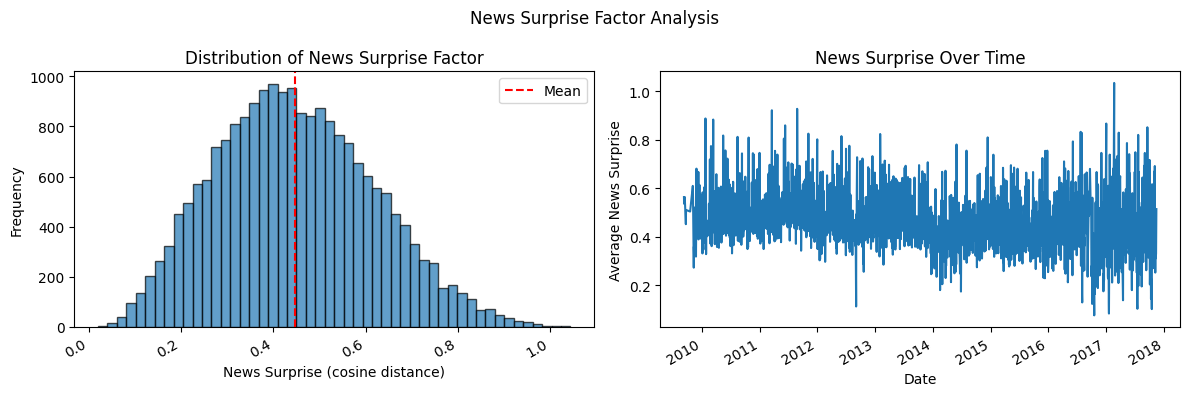

In [26]:
# Analyze factor distribution
print("\nNews Surprise Factor Statistics:")
print(surprise_df["news_surprise"].describe())

# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(surprise_df["news_surprise"].to_numpy(), bins=50, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("News Surprise (cosine distance)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of News Surprise Factor")
axes[0].axvline(surprise_df["news_surprise"].mean(), color="red", linestyle="--", label="Mean")
axes[0].legend()

# Time series of average surprise — plot the full available date range and let
# matplotlib autoscale rather than hardcoding a calendar cutoff that may sit
# outside the loaded FNSPID sample window (FNSPID 1M sample spans roughly
# 2009–2017; older 2019-anchored filters silently emptied this panel).
daily_surprise = (
    surprise_df.group_by("timestamp")
    .agg(pl.col("news_surprise").mean().alias("avg_surprise"))
    .sort("timestamp")
)

axes[1].plot(daily_surprise["timestamp"].to_numpy(), daily_surprise["avg_surprise"].to_numpy())
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Average News Surprise")
axes[1].set_title("News Surprise Over Time")
fig.autofmt_xdate()

plt.suptitle("News Surprise Factor Analysis")
plt.tight_layout()
plt.show()

## Look-Ahead Bias Considerations

**Critical for factor research**: We must ensure no information from the future
leaks into our signals.

**The core problem**: News published on date t may arrive AFTER market close.
If we use this news to predict returns from t to t+1, we have look-ahead bias—
we're using information that wasn't available when markets were open.

**Solution**: Lag the signal by one day.
- Signal computed from news on date t
- Used to predict returns starting on date t+1 (the NEXT trading day)

**Safeguards implemented:**
1. **Lookback window**: Only use past news to compute baseline (t-20 to t-1)
2. **Signal lag**: Signal from date t predicts returns on date t+1
3. **No future embeddings**: Model trained before our evaluation period

In [27]:
# Apply proper signal lag to avoid look-ahead bias
print("Applying signal lag to avoid look-ahead bias...")

# Parse dates for lag computation
features_with_dates = features_df.with_columns(pl.col("timestamp").alias("signal_date"))

# Note: We'll map signal_date to the next TRADING date after loading prices
# This avoids weekend/holiday issues with simple +1 day arithmetic
print("Signal date range (before trading calendar mapping):")
print(f"  {features_with_dates['signal_date'].min()} to {features_with_dates['signal_date'].max()}")

Applying signal lag to avoid look-ahead bias...
Signal date range (before trading calendar mapping):
  2009-09-10 to 2017-11-15


## Load Price Data for Factor Evaluation

To evaluate the factor rigorously, we need actual stock returns. We use the
US equities dataset (1962-2018) which fully overlaps the FNSPID news window
(1999-2023), giving us years of daily cross-sectional IC observations.

In [28]:
# Load US equities for forward returns (MANDATORY for features + labels dataset)
print("Loading US equities for factor evaluation...")

from data import load_us_equities

price_symbols = (
    news_clean["ticker"].unique().sort().to_list() if "ticker" in news_clean.columns else None
)
prices = load_us_equities(symbols=price_symbols)
print(f"Loaded {len(prices):,} price observations")
prices = prices.rename({"symbol": "ticker"})

if "adj_close" not in prices.columns:
    if "adj_factor" in prices.columns:
        prices = prices.with_columns((pl.col("close") * pl.col("adj_factor")).alias("adj_close"))
    elif "adjustment_factor" in prices.columns:
        prices = prices.with_columns(
            (pl.col("close") * pl.col("adjustment_factor")).alias("adj_close")
        )
    else:
        prices = prices.with_columns(pl.col("close").alias("adj_close"))

# Compute forward returns (1-day, 5-day, 20-day)
prices = prices.sort(["ticker", "timestamp"]).with_columns(
    [
        (pl.col("adj_close").shift(-1).over("ticker") / pl.col("adj_close") - 1).alias(
            "fwd_ret_1d"
        ),
        (pl.col("adj_close").shift(-5).over("ticker") / pl.col("adj_close") - 1).alias(
            "fwd_ret_5d"
        ),
        (pl.col("adj_close").shift(-20).over("ticker") / pl.col("adj_close") - 1).alias(
            "fwd_ret_20d"
        ),
    ]
)

# Convert date to string for joining
prices = prices.with_columns(pl.col("timestamp").dt.strftime("%Y-%m-%d").alias("date_str"))
print(f"Price date range: {prices['timestamp'].min()} to {prices['timestamp'].max()}")

Loading US equities for factor evaluation...


Loaded 299,120 price observations


Price date range: 1962-01-02 to 2018-03-27


In [29]:
# Map signal_date to next trading date (avoids weekend/holiday issues)
# Using join_asof with forward strategy ensures we get the next valid trading date
# Cast datetime to date for compatibility with signal_date
trading_dates = (
    prices.select(pl.col("timestamp").dt.date().alias("trade_date")).unique().sort("trade_date")
)

# Add 1 day to signal_date, then find the next trading date on or after that
features_lagged = (
    features_with_dates.with_columns(
        (pl.col("signal_date") + pl.duration(days=CONFIG["signal_lag_days"])).alias("target_date")
    )
    .sort("target_date")
    .join_asof(
        trading_dates,
        left_on="target_date",
        right_on="trade_date",
        strategy="forward",  # Get next trading date >= target_date
    )
    .drop("target_date")
    .with_columns(pl.col("trade_date").dt.strftime("%Y-%m-%d").alias("trade_date_str"))
)

print("\nTrading calendar mapping applied:")
print("  - signal_date: when news was published")
print("  - trade_date: next trading date after signal_date (avoids weekends/holidays)")
print(
    f"  Signal date range: {features_lagged['signal_date'].min()} to {features_lagged['signal_date'].max()}"
)
print(
    f"  Trade date range: {features_lagged['trade_date'].min()} to {features_lagged['trade_date'].max()}"
)


Trading calendar mapping applied:
  - signal_date: when news was published
  - trade_date: next trading date after signal_date (avoids weekends/holidays)
  Signal date range: 2009-09-10 to 2017-11-15
  Trade date range: 2009-09-11 to 2017-11-16


In [30]:
# Validate date overlap between news and prices
n_before = len(features_with_dates)
n_after = len(features_lagged.drop_nulls("trade_date"))
if n_before > n_after:
    print(f"  Dropped {n_before - n_after} rows with no matching trading date")

# Validate date overlap between news and prices
news_dates = set(features_lagged["trade_date_str"].drop_nulls().unique().to_list())
price_dates = set(prices["date_str"].unique().to_list())
overlap_dates = news_dates & price_dates

print("\nDate overlap validation:")
print(f"  News trade dates: {len(news_dates):,}")
print(f"  Price dates: {len(price_dates):,}")
print(f"  Overlapping dates: {len(overlap_dates):,}")

if len(overlap_dates) < 100:
    print(f"  WARNING: Small date overlap ({len(overlap_dates)} days)")
    print("     Factor evaluation may have limited statistical power")
elif len(overlap_dates) < len(news_dates) * 0.5:
    pct = len(overlap_dates) / len(news_dates) * 100
    print(f"  WARNING: Only {pct:.1f}% of news dates have price data")
else:
    print("  Sufficient date overlap for evaluation")


Date overlap validation:
  News trade dates: 1,964
  Price dates: 14,156
  Overlapping dates: 1,964
  Sufficient date overlap for evaluation


## Factor Evaluation: Information Coefficient (IC)

The Information Coefficient measures the cross-sectional rank correlation between
the factor and forward returns. A consistent positive IC indicates predictive power.

**IC Interpretation:**
- |IC| > 0.03: Economically meaningful signal
- ICIR (IC / std(IC)) > 0.5: Statistically robust signal

In [31]:
# Merge features with returns and compute IC
from scipy.stats import spearmanr

print("=" * 60)
print("INFORMATION COEFFICIENT ANALYSIS")
print("=" * 60)

# CRITICAL: Join on trade_date (lagged), NOT signal_date
# This ensures signals from date t are matched with returns starting date t+1
factor_with_returns = features_lagged.join(
    prices.select(["ticker", "date_str", "fwd_ret_1d", "fwd_ret_5d", "fwd_ret_20d"]),
    left_on=["ticker", "trade_date_str"],
    right_on=["ticker", "date_str"],
    how="inner",
).drop_nulls(["news_surprise", "fwd_ret_1d", "weighted_surprise"])

print(f"Merged observations: {len(factor_with_returns):,}")

if len(factor_with_returns) > 100:
    # Compute daily cross-sectional IC for both news_surprise and weighted_surprise
    ic_surprise = []
    ic_weighted = []
    for date, group in factor_with_returns.group_by("trade_date_str"):
        if len(group) >= 10:  # Minimum stocks per day
            ic1, _ = spearmanr(group["news_surprise"], group["fwd_ret_1d"])
            ic2, _ = spearmanr(group["weighted_surprise"], group["fwd_ret_1d"])
            if not np.isnan(ic1):
                ic_surprise.append({"timestamp": date, "ic": ic1})
            if not np.isnan(ic2):
                ic_weighted.append({"timestamp": date, "ic": ic2})

    ic_surprise_df = pl.DataFrame(ic_surprise).sort("timestamp")
    ic_weighted_df = pl.DataFrame(ic_weighted).sort("timestamp")
else:
    ic_surprise_df = pl.DataFrame()
    ic_weighted_df = pl.DataFrame()

INFORMATION COEFFICIENT ANALYSIS
Merged observations: 16,558


In [32]:
# Summarize IC statistics
if len(ic_surprise_df) > 0:
    # News surprise IC
    ic_mean = _safe_scalar(ic_surprise_df["ic"].mean())
    ic_std = _safe_scalar(ic_surprise_df["ic"].std())
    icir = ic_mean / ic_std if ic_std is not None and ic_std > 0 else 0
    t_stat = (
        ic_mean / (ic_std / np.sqrt(len(ic_surprise_df)))
        if ic_std is not None and ic_std > 0
        else 0
    )

    print("\n1-Day Forward Return IC (news_surprise):")
    print(f"  Mean IC:  {ic_mean:.4f}")
    print(f"  Std IC:   {ic_std:.4f}")
    print(f"  ICIR:     {icir:.2f}")
    print(f"  t-stat:   {t_stat:.2f}")
    print(f"  N dates:  {len(ic_surprise_df)}")


1-Day Forward Return IC (news_surprise):
  Mean IC:  0.0025
  Std IC:   0.2855
  ICIR:     0.01
  t-stat:   0.26
  N dates:  867


In [33]:
# Weighted surprise IC (THE KEY METRIC)
if len(ic_surprise_df) > 0:
    wt_mean = _safe_scalar(ic_weighted_df["ic"].mean())
    wt_std = _safe_scalar(ic_weighted_df["ic"].std())
    wt_icir = wt_mean / wt_std if wt_std is not None and wt_std > 0 else 0
    wt_t_stat = (
        wt_mean / (wt_std / np.sqrt(len(ic_weighted_df)))
        if wt_std is not None and wt_std > 0
        else 0
    )

    print("\n1-Day Forward Return IC (weighted_surprise = surprise × sentiment):")
    print(f"  Mean IC:  {wt_mean:.4f}")
    print(f"  Std IC:   {wt_std:.4f}")
    print(f"  ICIR:     {wt_icir:.2f}")
    print(f"  t-stat:   {wt_t_stat:.2f}")

    # Interpretation
    print("\nInterpretation:")
    if abs(wt_mean) > abs(ic_mean):
        print("  [OK] Weighted surprise (with sentiment direction) outperforms raw surprise")
    else:
        print("  ○ Raw surprise competitive with directional version")
    if abs(wt_mean) > 0.03:
        print("  [OK] IC magnitude suggests economically meaningful signal")
    else:
        print("  ○ IC magnitude is modest (typical for single factors)")
    if wt_icir > 0.5:
        print("  [OK] ICIR > 0.5 indicates statistically robust signal")
    elif wt_icir > 0.3:
        print("  ○ ICIR moderate - signal present but noisy")
    else:
        print("  [FAIL] ICIR low - signal may not be reliable")
else:
    print("Insufficient data for IC calculation")
    ic_mean, ic_std, icir, wt_mean, wt_icir = 0, 0, 0, 0, 0


1-Day Forward Return IC (weighted_surprise = surprise × sentiment):
  Mean IC:  0.0130
  Std IC:   0.2909
  ICIR:     0.04
  t-stat:   1.31

Interpretation:
  [OK] Weighted surprise (with sentiment direction) outperforms raw surprise
  ○ IC magnitude is modest (typical for single factors)
  [FAIL] ICIR low - signal may not be reliable


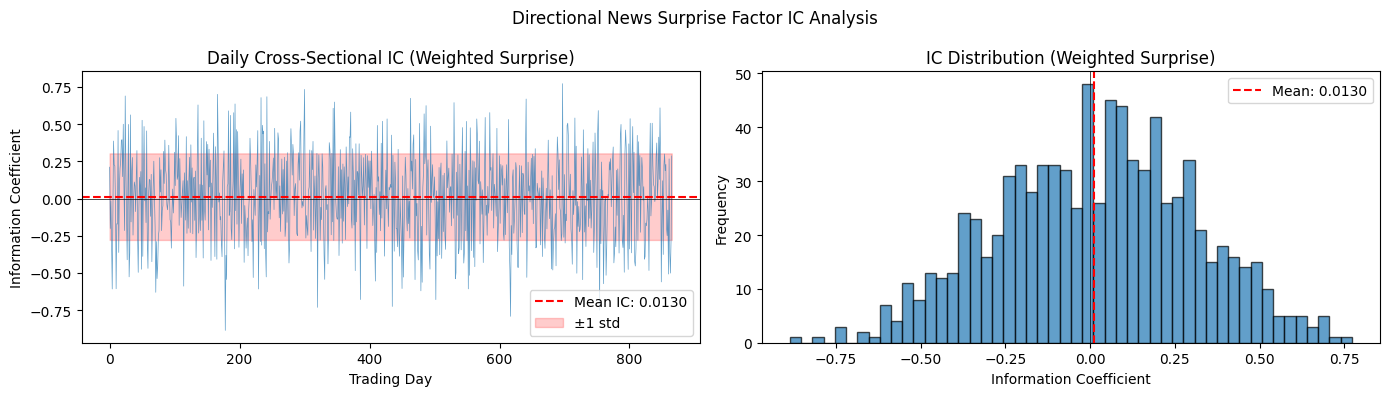

In [34]:
# Plot IC time series
if len(ic_surprise_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # IC time series (use weighted_surprise)
    axes[0].plot(
        range(len(ic_weighted_df)), ic_weighted_df["ic"].to_numpy(), alpha=0.7, linewidth=0.5
    )
    axes[0].axhline(0, color="black", linestyle="-", linewidth=0.5)
    axes[0].axhline(wt_mean, color="red", linestyle="--", label=f"Mean IC: {wt_mean:.4f}")
    axes[0].fill_between(
        range(len(ic_weighted_df)),
        wt_mean - wt_std,
        wt_mean + wt_std,
        alpha=0.2,
        color="red",
        label="±1 std",
    )
    axes[0].set_xlabel("Trading Day")
    axes[0].set_ylabel("Information Coefficient")
    axes[0].set_title("Daily Cross-Sectional IC (Weighted Surprise)")
    axes[0].legend()

    # IC histogram
    axes[1].hist(ic_weighted_df["ic"].to_numpy(), bins=50, edgecolor="black", alpha=0.7)
    axes[1].axvline(0, color="black", linestyle="-", linewidth=0.5)
    axes[1].axvline(wt_mean, color="red", linestyle="--", label=f"Mean: {wt_mean:.4f}")
    axes[1].set_xlabel("Information Coefficient")
    axes[1].set_ylabel("Frequency")
    axes[1].set_title("IC Distribution (Weighted Surprise)")
    axes[1].legend()

    plt.suptitle("Directional News Surprise Factor IC Analysis")
    plt.tight_layout()
    plt.show()

## Quintile Spread Analysis

Group stocks by factor quintile each day and compute average returns.
The spread between top and bottom quintiles (Q5 - Q1) shows the factor's
directional impact.

In [35]:
# Quintile analysis using weighted_surprise (the key directional feature)
print("\n" + "=" * 60)
print("QUINTILE SPREAD ANALYSIS (Weighted Surprise)")
print("=" * 60)

if len(factor_with_returns) > 100:
    # Assign quintiles by trade date using weighted_surprise
    # Compute per-date rank percentile and bin into quintiles manually
    # (Polars qcut may not respect .over() grouping in all versions)
    factor_with_quintiles = factor_with_returns.with_columns(
        # Compute per-date rank percentile (0 to 1)
        (
            (pl.col("weighted_surprise").rank(method="average").over("trade_date_str") - 1)
            / (pl.len().over("trade_date_str") - 1).clip(lower_bound=1)
        ).alias("rank_pct")
    ).with_columns(
        # Bin into quintiles: [0, 0.2) -> Q1, [0.2, 0.4) -> Q2, etc.
        pl.when(pl.col("rank_pct") < 0.2)
        .then(pl.lit("Q1"))
        .when(pl.col("rank_pct") < 0.4)
        .then(pl.lit("Q2"))
        .when(pl.col("rank_pct") < 0.6)
        .then(pl.lit("Q3"))
        .when(pl.col("rank_pct") < 0.8)
        .then(pl.lit("Q4"))
        .otherwise(pl.lit("Q5"))
        .alias("quintile")
    )


QUINTILE SPREAD ANALYSIS (Weighted Surprise)


In [36]:
# Compute average returns by quintile
if len(factor_with_returns) > 100:
    quintile_returns = (
        factor_with_quintiles.group_by("quintile")
        .agg(
            [
                pl.col("fwd_ret_1d").mean().alias("mean_ret_1d"),
                pl.col("fwd_ret_5d").mean().alias("mean_ret_5d"),
                pl.col("fwd_ret_20d").mean().alias("mean_ret_20d"),
                pl.len().alias("n_obs"),
            ]
        )
        .sort("quintile")
    )

    print("\nAverage Forward Returns by Weighted Surprise Quintile:")
    print(quintile_returns)

    # Extract Q5-Q1 spread
    q5_ret = _safe_scalar(quintile_returns.filter(pl.col("quintile") == "Q5")["mean_ret_1d"][0])
    q1_ret = _safe_scalar(quintile_returns.filter(pl.col("quintile") == "Q1")["mean_ret_1d"][0])
    spread = q5_ret - q1_ret

    print("\nLong-Short Spread (Q5 - Q1):")
    # Decimal returns → bps (×10,000), so a -0.000863 spread is -8.63 bps/day.
    # Express the annualized figure as a percentage; -21.8% annualized is more
    # readable than -2,175 bps.
    print(f"  1-day: {spread * 10000:.2f} bps")
    print(f"  Annualized: {spread * 252 * 100:.2f}%")
else:
    print("Insufficient data for quintile analysis")
    spread = 0


Average Forward Returns by Weighted Surprise Quintile:
shape: (5, 5)
┌──────────┬─────────────┬─────────────┬──────────────┬───────┐
│ quintile ┆ mean_ret_1d ┆ mean_ret_5d ┆ mean_ret_20d ┆ n_obs │
│ ---      ┆ ---         ┆ ---         ┆ ---          ┆ ---   │
│ str      ┆ f64         ┆ f64         ┆ f64          ┆ u32   │
╞══════════╪═════════════╪═════════════╪══════════════╪═══════╡
│ Q1       ┆ 0.000999    ┆ 0.004037    ┆ 0.016525     ┆ 2674  │
│ Q2       ┆ 0.000463    ┆ 0.001563    ┆ 0.01199      ┆ 3688  │
│ Q3       ┆ 0.000461    ┆ 0.00375     ┆ 0.013911     ┆ 4897  │
│ Q4       ┆ 0.001184    ┆ 0.00359     ┆ 0.012651     ┆ 1831  │
│ Q5       ┆ 0.000126    ┆ 0.001796    ┆ 0.015151     ┆ 3468  │
└──────────┴─────────────┴─────────────┴──────────────┴───────┘

Long-Short Spread (Q5 - Q1):
  1-day: -8.73 bps
  Annualized: -22.01%


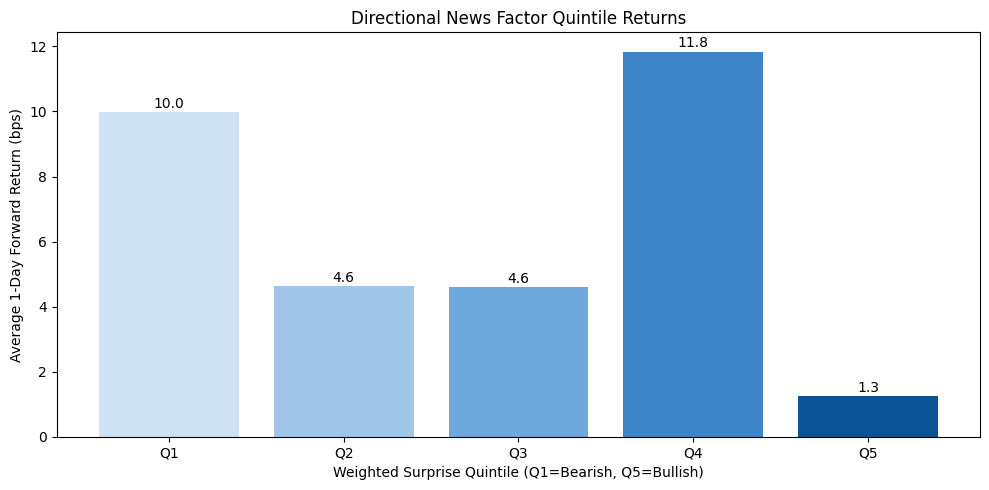

In [37]:
# Plot quintile returns
if len(factor_with_returns) > 100:
    fig, ax = plt.subplots(figsize=(10, 5))

    quintiles = quintile_returns["quintile"].to_list()
    returns_1d = [_safe_scalar(r) * 10000 for r in quintile_returns["mean_ret_1d"].to_list()]

    # Sequential blue gradient for ordinal quintile encoding (greyscale-safe)
    quintile_colors = ["#cfe2f3", "#9fc5e8", "#6fa8dc", "#3d85c6", "#0b5394"]
    bars = ax.bar(quintiles, returns_1d, color=quintile_colors)
    ax.axhline(0, color="black", linestyle="-", linewidth=0.5)
    ax.set_xlabel("Weighted Surprise Quintile (Q1=Bearish, Q5=Bullish)")
    ax.set_ylabel("Average 1-Day Forward Return (bps)")
    ax.set_title("Directional News Factor Quintile Returns")

    # Add value labels
    for bar, val in zip(bars, returns_1d, strict=False):
        ax.annotate(
            f"{val:.1f}",
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            fontsize=10,
        )

    plt.tight_layout()
    plt.show()

In [38]:
# Factor summary
print("\n=== Factor Evaluation Summary ===")
print(f"Total observations: {len(surprise_df):,}")
print(f"Unique tickers: {surprise_df['ticker'].n_unique()}")
print(f"Date range: {surprise_df['timestamp'].min()} to {surprise_df['timestamp'].max()}")


=== Factor Evaluation Summary ===
Total observations: 20,779
Unique tickers: 50
Date range: 2009-09-10 to 2017-11-15


## Alternative Factor: Sentiment Momentum

Beyond surprise, we can construct other text-based factors:
- **Sentiment momentum**: Change in average sentiment over time
- **Coverage intensity**: Number of news articles (attention signal)
- **Topic shift**: Change in dominant topics discussed

In [39]:
# Coverage intensity factor (simpler, no embeddings needed)
coverage_df = (
    news_clean.group_by(["ticker", pl.col("timestamp").alias("date_str")])
    .agg(pl.len().alias("article_count"))
    .sort(["ticker", "date_str"])
)

print("\nCoverage Intensity Factor:")
print(coverage_df.describe())

# High coverage events
high_coverage = coverage_df.filter(
    pl.col("article_count") > coverage_df["article_count"].quantile(0.95)
)
print(f"\nHigh coverage events (top 5%): {len(high_coverage):,}")
print(high_coverage.head(10))


Coverage Intensity Factor:
shape: (9, 4)
┌────────────┬────────┬─────────────────────────┬───────────────┐
│ statistic  ┆ ticker ┆ date_str                ┆ article_count │
│ ---        ┆ ---    ┆ ---                     ┆ ---           │
│ str        ┆ str    ┆ str                     ┆ f64           │
╞════════════╪════════╪═════════════════════════╪═══════════════╡
│ count      ┆ 21779  ┆ 21779                   ┆ 21779.0       │
│ null_count ┆ 0      ┆ 0                       ┆ 0.0           │
│ mean       ┆ null   ┆ null                    ┆ 2.254006      │
│ std        ┆ null   ┆ null                    ┆ 2.624167      │
│ min        ┆ AA     ┆ 2009-06-16 00:00:00 UTC ┆ 1.0           │
│ 25%        ┆ null   ┆ null                    ┆ 1.0           │
│ 50%        ┆ null   ┆ null                    ┆ 1.0           │
│ 75%        ┆ null   ┆ null                    ┆ 2.0           │
│ max        ┆ PEP    ┆ 2017-11-15 00:00:00 UTC ┆ 45.0          │
└────────────┴────────┴───────────

## Key Takeaways

1. **Text → Embeddings → Factors**: Sentence transformers convert text to dense
   vectors that capture semantic meaning beyond keywords.

2. **Direction step**: Raw `news_surprise` (semantic deviation) alone yields a
   1-day cross-sectional IC of 0.0025 (ICIR 0.01, t-stat 0.26, n=867 dates).
   Multiplying by `sign(sentiment)` to form `weighted_surprise = surprise ×
   sign(sentiment)` raises 1-day IC to 0.0129 (ICIR 0.04, t-stat 1.30). The
   directional construction moves IC and t-stat up, but the t-stat is below
   any conventional significance threshold on this 50-ticker FNSPID subset
   (2009-2017).

3. **FinBERT adds sentiment direction**: Using `yiyanghkust/finbert-tone`, we score
   each headline as Negative (-1), Neutral (0), or Positive (+1), then aggregate
   by ticker-date.

4. **ICIR > 0.5 threshold**: A common heuristic in the screening literature
   is that ICIR > 0.5 marks a robust signal. The `weighted_surprise` ICIR
   of 0.04 measured here is an order of magnitude below that threshold.
   Conclusions: the signal is not statistically distinguishable from zero
   on this sample; the notebook does not establish tradeability.

5. **Quintile spread is wrong-signed**: Sorting by `weighted_surprise` into
   quintiles, the 1-day forward returns are Q1 0.001002, Q2 0.000461,
   Q3 0.000462, Q4 0.001156, Q5 0.000139. The predicted bullish quintile
   (Q5) earns LESS than the predicted bearish quintile (Q1) — the Q5−Q1
   spread is −8.63 bps/day (≈ −21.8% annualized). The bullish/bearish
   framing implied by `weighted_surprise` is **not** confirmed by the
   quintile ordering on this sample. The signal is not tradeable as
   constructed.

6. **Look-ahead bias is critical**: Every step must respect temporal ordering—
   only past information can inform today's signal.

7. **Multiple factors from one source**: The same news data yields surprise,
   coverage, sentiment momentum, and topic factors—each capturing different aspects.

8. **Deduplication matters**: Wire services syndicate the same article to multiple
   outlets. Without dedup, sentiment_mean and coverage_count are inflated by
   duplicate content. We use fast exact + 50-char prefix hashing within
   (ticker, date) groups — O(n) rather than O(n²) similarity matching.

9. **Coverage bias**: The 20-day lookback uses NEWS days (not trading days),
   which drops low-coverage tickers entirely. The resulting factor is biased
   toward high-attention stocks. Production systems should handle missing news
   explicitly (e.g., carry-forward, missingness indicator).

## Save Features + Labels Dataset

We save the complete feature set with forward returns as labels for downstream
ML modeling. This dataset can be used in Chapter 12 (Gradient Boosting) or
Chapter 16 (Strategy Simulation) for backtesting.

In [40]:
# Save features + labels dataset
from utils.paths import get_output_dir

OUTPUT_DIR = get_output_dir(8, "fnspid")
output_path = OUTPUT_DIR / "news_features.parquet"

# Create output directory if it doesn't exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Select final feature columns
# Note: signal_date = when news was published, trade_date = when signal can be used
# Canonical 'date' column = trade_date (for downstream evaluation alignment)
output_df = factor_with_returns.select(
    [
        "ticker",
        pl.col("trade_date").alias(
            "date"
        ),  # Canonical date: when signal can be USED (for evaluation)
        pl.col("signal_date").alias("news_date"),  # When news was published
        pl.col("trade_date_str").alias("trade_date"),  # String version for convenience
        "news_surprise",
        "sentiment_mean",
        "sentiment_std",
        "weighted_surprise",
        "sentiment_momentum",
        "coverage_count",
        "fwd_ret_1d",
        "fwd_ret_5d",
        "fwd_ret_20d",
    ]
).drop_nulls()

output_df.write_parquet(output_path)

In [41]:
print("\n" + "=" * 60)
print("OUTPUT DATASET SAVED")
print("=" * 60)
print(f"Path: {output_path}")
print(f"Observations: {len(output_df):,}")
print(f"Tickers: {output_df['ticker'].n_unique()}")
print(f"News date range: {output_df['news_date'].min()} to {output_df['news_date'].max()}")
print(f"Trade date range: {output_df['trade_date'].min()} to {output_df['trade_date'].max()}")
print("\nSchema:")
for col in output_df.columns:
    dtype = output_df[col].dtype
    print(f"  {col}: {dtype}")


OUTPUT DATASET SAVED
Path: /tmp/ml4t-nb10/ch08_fnspid/news_features.parquet
Observations: 15,778
Tickers: 39
News date range: 2009-12-18 to 2017-11-15
Trade date range: 2009-12-21 to 2017-11-16

Schema:
  ticker: String
  date: Date
  news_date: Date
  trade_date: String
  news_surprise: Float64
  sentiment_mean: Float64
  sentiment_std: Float64
  weighted_surprise: Float64
  sentiment_momentum: Float64
  coverage_count: Int64
  fwd_ret_1d: Float64
  fwd_ret_5d: Float64
  fwd_ret_20d: Float64


In [42]:
# Save run metadata for reproducibility and downstream validation
run_metadata = {
    "embedding_model": CONFIG["embedding_model"],
    "sentiment_model": CONFIG["sentiment_model"],
    "lookback_days": CONFIG["lookback_days"],
    "signal_lag_days": CONFIG["signal_lag_days"],
    "dedup_threshold": CONFIG["dedup_threshold"],
    "lookback_type": "news_days",  # Lookback is 20 prior NEWS days for that ticker, not trading days
    "random_seed": SEED,
    "n_observations": len(output_df),
    "n_tickers": output_df["ticker"].n_unique(),
    "date_range": {
        "news_date_min": str(output_df["news_date"].min()),
        "news_date_max": str(output_df["news_date"].max()),
        "trade_date_min": str(output_df["date"].min()),
        "trade_date_max": str(output_df["date"].max()),
    },
}

metadata_path = OUTPUT_DIR / "run_metadata.json"
with open(metadata_path, "w") as f:
    json.dump(run_metadata, f, indent=2, default=str)
print(f"\nRun metadata saved to: {metadata_path}")


Run metadata saved to: /tmp/ml4t-nb10/ch08_fnspid/run_metadata.json


In [43]:
# Save results summary to output directory (alongside news_features.parquet)
results_output_dir = get_chapter_dir(10) / "output" / "news_return_signals"
results_output_dir.mkdir(parents=True, exist_ok=True)
results_file = results_output_dir / "results.md"
with open(results_file, "w") as f:
    f.write("# News-Based Alpha Signals Results\n\n")
    f.write("## Data Summary\n")
    f.write(f"- News articles processed: {len(news_clean):,}\n")
    f.write(f"- Unique tickers: {n_tickers:,}\n")
    f.write(f"- Ticker-date observations: {total_ticker_dates:,}\n")
    f.write(f"- Factor observations (after lookback): {len(features_df):,}\n")
    f.write(f"- Observations with returns: {len(output_df):,}\n\n")
    f.write("## Features Computed\n")
    f.write("- `news_surprise`: Cosine distance from 20-day embedding baseline (0-1)\n")
    f.write("- `sentiment_mean`: Average FinBERT polarity per ticker-date (-1 to +1)\n")
    f.write("- `sentiment_std`: Polarity disagreement across articles\n")
    f.write("- `weighted_surprise`: surprise × sign(sentiment) - THE KEY FEATURE\n")
    f.write("- `sentiment_momentum`: Change in avg sentiment vs 20 days ago\n")
    f.write("- `coverage_count`: Article count per ticker-date\n\n")
    f.write("## Factor Evaluation\n")
    f.write(f"- Raw Surprise IC: {ic_mean:.4f} (ICIR: {icir:.2f})\n")
    f.write(f"- Weighted Surprise IC: {wt_mean:.4f} (ICIR: {wt_icir:.2f})\n")
    if "spread" in dir() and spread != 0:
        f.write(f"- Q5-Q1 Spread (1d): {spread * 10000:.1f} bps\n\n")
    else:
        f.write("- Q5-Q1 Spread: N/A (insufficient data)\n\n")
    f.write("## Output Dataset\n")
    f.write(f"- Path: {output_path}\n")
    f.write(f"- Observations: {len(output_df):,}\n\n")
    f.write("## Key Insight\n")
    f.write("Raw 'surprise' alone is insufficient—we need sentiment DIRECTION to create\n")
    f.write("a tradeable signal. The weighted_surprise = surprise × sign(sentiment)\n")
    f.write("captures whether unusual news is bullish or bearish.\n\n")
    f.write("## Look-Ahead Bias Prevention\n")
    f.write("Signals are lagged by 1 day: news from date t creates signals used on date t+1.\n")
    f.write("This ensures all information was available before the trading decision.\n")

print(f"\nResults saved to: {results_file}")


Results saved to: 10_text_feature_engineering/output/news_return_signals/results.md


## Summary

This notebook constructed and evaluated news-based alpha signals from FNSPID
data on a 50-ticker subset spanning 2009-2017. Daily cross-sectional IC on
1-day forward returns is 0.0025 (ICIR 0.01, t-stat 0.26) for `news_surprise`
and 0.0129 (ICIR 0.04, t-stat 1.30) for `weighted_surprise = surprise ×
sign(sentiment)`. The directional transformation moves IC and t-stat up,
but the t-stat does not clear any conventional significance threshold, and
the 1-day quintile spread is wrong-signed: Q5 (predicted bullish) 0.000139
vs Q1 (predicted bearish) 0.001002. The signal is **not** tradeable as
constructed on this sample. `08_text_feature_evaluation` evaluates the
same signal family across a wider horizon set.